In [42]:
import pandas as pd
import numpy as np

In [43]:
data = pd.read_csv("wind_data.csv")
data.head()

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,SOURCE,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,MA1,TMP,WND
0,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-02T03:00:00,4,FM-12,99999,V020,"99999,9,10101,1","+0282,1","999,9,C,0000,1"
1,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-03T03:00:00,4,FM-12,99999,V020,"99999,9,10109,1","+0280,1","999,9,C,0000,1"
2,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-03T06:00:00,4,FM-12,99999,V020,"99999,9,10115,1","+0324,1","999,9,C,0000,1"
3,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-03T09:00:00,4,FM-12,99999,V020,"99999,9,10082,1","+0344,1","320,1,N,0010,1"
4,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-03T12:00:00,4,FM-12,99999,V020,"99999,9,10077,1","+0338,1","999,9,C,0000,1"


In [44]:
print(data.shape)

(43879, 13)


In [45]:
data[data["WND"] == "999,9,C,0000,1"].shape[0]

4095

In [46]:
data[data["TMP"] == "9999,9"].shape[0]

0

In [47]:
data = data[data["WND"] != "999,9,C,0000,1"]
data = data[data["TMP"] != "9999,9"]

In [48]:
data["DATE"] = pd.to_datetime(data["DATE"])
data.head(2)

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,SOURCE,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,MA1,TMP,WND
3,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-03 09:00:00,4,FM-12,99999,V020,"99999,9,10082,1","+0344,1","320,1,N,0010,1"
6,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-04 09:00:00,4,FM-12,99999,V020,"99999,9,10083,1","+0350,1","290,1,N,0010,1"


In [49]:
def extract_wind_speed(wnd):
    try:
        parts = wnd.split(",")
        if len(parts) >= 4:
            wind_direction_deg = int(parts[0])
            wind_speed_tenths = float(parts[3])
            wind_speed_mps = wind_speed_tenths / 10
            return pd.Series([wind_direction_deg, wind_speed_mps])
        else:
            return pd.Series([None, None])
    except:
        return pd.Series([None, None])

data[["wind_direction_deg","wind_speed_mps"]] = data["WND"].apply(extract_wind_speed)

In [50]:
data.drop(columns = "WND", inplace = True)
data.head(2)

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,SOURCE,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,MA1,TMP,wind_direction_deg,wind_speed_mps
3,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-03 09:00:00,4,FM-12,99999,V020,"99999,9,10082,1","+0344,1",320.0,1.0
6,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-04 09:00:00,4,FM-12,99999,V020,"99999,9,10083,1","+0350,1",290.0,1.0


In [51]:
#converting TMP in degree celsius

data["tmp_deg"] = data["TMP"].str.split(",").str[0]
data["tmp_deg"] = data["tmp_deg"].astype(int)
data["tmp_deg"] = data["tmp_deg"]/10

In [52]:
data["tmp_deg"].head(2)

3    34.4
6    35.0
Name: tmp_deg, dtype: float64

In [53]:
data.head(10)

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,SOURCE,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,MA1,TMP,wind_direction_deg,wind_speed_mps,tmp_deg
3,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-03 09:00:00,4,FM-12,99999,V020,"99999,9,10082,1","+0344,1",320.0,1.0,34.4
6,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-04 09:00:00,4,FM-12,99999,V020,"99999,9,10083,1","+0350,1",290.0,1.0,35.0
7,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-04 12:00:00,4,FM-12,99999,V020,"99999,9,10076,1","+0328,1",320.0,1.5,32.8
10,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-05 09:00:00,4,FM-12,99999,V020,"99999,9,10074,1","+0346,1",320.0,1.5,34.6
11,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-05 12:00:00,4,FM-12,99999,V020,"99999,9,10067,1","+0328,1",320.0,1.5,32.8
13,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-06 09:00:00,4,FM-12,99999,V020,"99999,9,10058,1","+0346,1",320.0,1.0,34.6
14,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-06 12:00:00,4,FM-12,99999,V020,"99999,9,10049,1","+0332,1",320.0,1.0,33.2
21,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-08 12:00:00,4,FM-12,99999,V020,"99999,9,10066,1","+0334,1",320.0,1.0,33.4
33,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-11 12:00:00,4,FM-12,99999,V020,"99999,9,10076,1","+0338,1",320.0,1.0,33.8
37,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-12 12:00:00,4,FM-12,99999,V020,"99999,9,10076,1","+0338,1",320.0,1.0,33.8


In [54]:
(data['wind_speed_mps'] == 0).sum()

np.int64(1)

In [55]:
(data['wind_speed_mps'] == 0).mean() * 100 

np.float64(0.0025135732957973053)

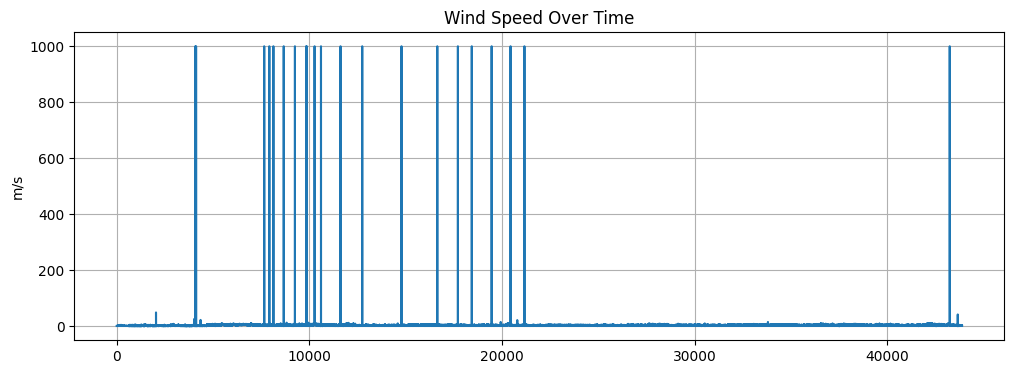

In [56]:
import matplotlib.pyplot as plt

data["wind_speed_mps"].plot(figsize = (12, 4))
plt.title('Wind Speed Over Time')
plt.ylabel('m/s')
plt.grid()
plt.show()

In [57]:
print("Min:", data['wind_speed_mps'].min())
print("Max:", data['wind_speed_mps'].max())

Min: 0.0
Max: 999.9


In [58]:
#counting outliners
(data['wind_speed_mps'] >= 60).sum() #np.int64(24)

np.int64(24)

In [59]:
#since outliners are less so removing them
data = data[data["wind_speed_mps"]<60].copy()

In [60]:
data.head(5)

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,SOURCE,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,MA1,TMP,wind_direction_deg,wind_speed_mps,tmp_deg
3,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-03 09:00:00,4,FM-12,99999,V020,"99999,9,10082,1","+0344,1",320.0,1.0,34.4
6,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-04 09:00:00,4,FM-12,99999,V020,"99999,9,10083,1","+0350,1",290.0,1.0,35.0
7,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-04 12:00:00,4,FM-12,99999,V020,"99999,9,10076,1","+0328,1",320.0,1.5,32.8
10,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-05 09:00:00,4,FM-12,99999,V020,"99999,9,10074,1","+0346,1",320.0,1.5,34.6
11,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-05 12:00:00,4,FM-12,99999,V020,"99999,9,10067,1","+0328,1",320.0,1.5,32.8


In [61]:
(data['wind_speed_mps'] < 60).sum() #np.int64(43855)

np.int64(39760)

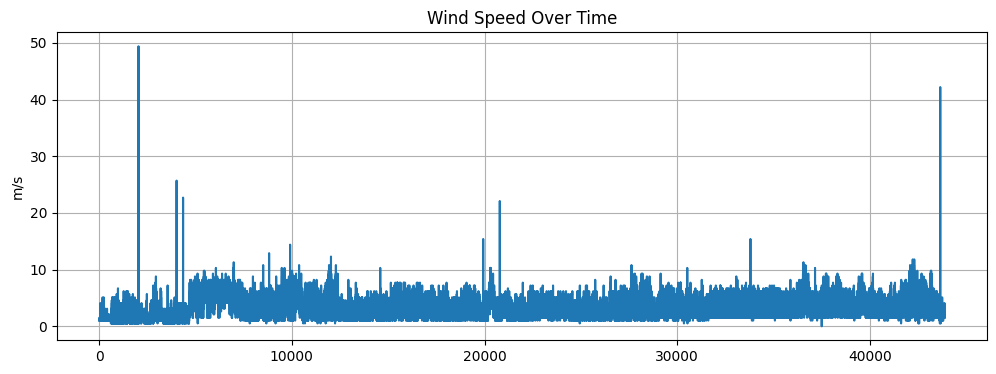

In [62]:
data["wind_speed_mps"].plot(figsize = (12, 4))
plt.title('Wind Speed Over Time')
plt.ylabel('m/s')
plt.grid()
plt.show()

In [63]:
data["wind_speed_mps"].describe()

count    39760.000000
mean         3.380020
std          1.771295
min          0.000000
25%          2.100000
50%          3.100000
75%          4.600000
max         49.400000
Name: wind_speed_mps, dtype: float64

In [64]:
# Returns power output in kW for a given wind speed in m/s based on the discrete power curve of the Suzlon S66 turbine.
def suzlon_s66_power_output(wind_speed):
    if wind_speed < 4:
        return 0
    elif wind_speed < 5:
        return 50
    elif wind_speed < 6:
        return 100
    elif wind_speed < 7:
        return 200
    elif wind_speed < 8:
        return 350
    elif wind_speed < 9:
        return 550
    elif wind_speed < 10:
        return 800
    elif wind_speed < 11:
        return 1000
    elif wind_speed < 12:
        return 1150
    elif wind_speed < 13:
        return 1225
    elif wind_speed < 25:
        return 1250
    else:
        return 0

In [65]:
data["power_output_kw"] = data["wind_speed_mps"].apply(suzlon_s66_power_output)

In [66]:
data["power_output_kw"].describe()

count    39760.000000
mean        46.678823
std         99.039971
min          0.000000
25%          0.000000
50%          0.000000
75%         50.000000
max       1250.000000
Name: power_output_kw, dtype: float64

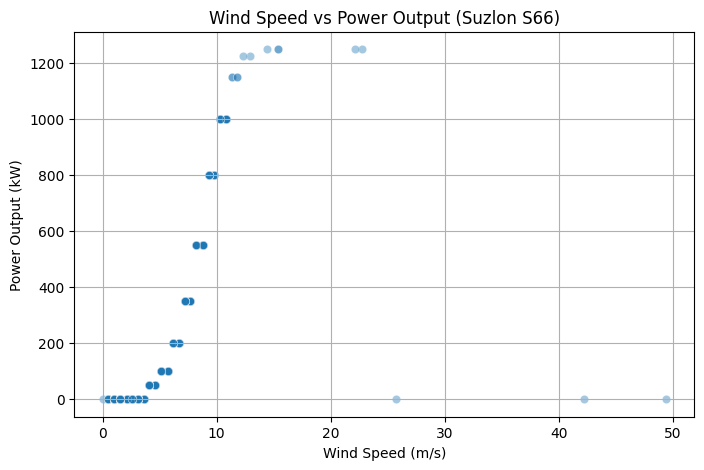

In [67]:
import seaborn as sns
plt.figure(figsize = (8, 5))
sns.scatterplot(x = "wind_speed_mps", y = "power_output_kw", data = data, alpha = 0.4)
plt.title("Wind Speed vs Power Output (Suzlon S66)")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Power Output (kW)")
plt.grid(True)
plt.show()

In [68]:
filtered_data = data[(data["wind_speed_mps"] >= 3.5) & (data["wind_speed_mps"] <= 25)]
print(f"Total rows: {len(data)}")
print(f"Filtered rows: {len(filtered_data)}")
print(f"Percentage retained: {100 * len(filtered_data)/len(data):.2f}%")
filtered_data = filtered_data.copy()

Total rows: 39760
Filtered rows: 17674
Percentage retained: 44.45%


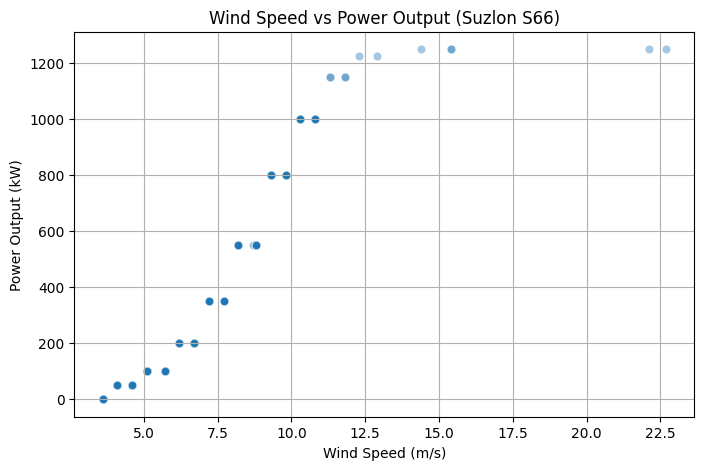

In [69]:
plt.figure(figsize = (8, 5))
sns.scatterplot(x = "wind_speed_mps", y = "power_output_kw", data = filtered_data, alpha = 0.4)
plt.title("Wind Speed vs Power Output (Suzlon S66)")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Power Output (kW)")
plt.grid(True)
plt.show()

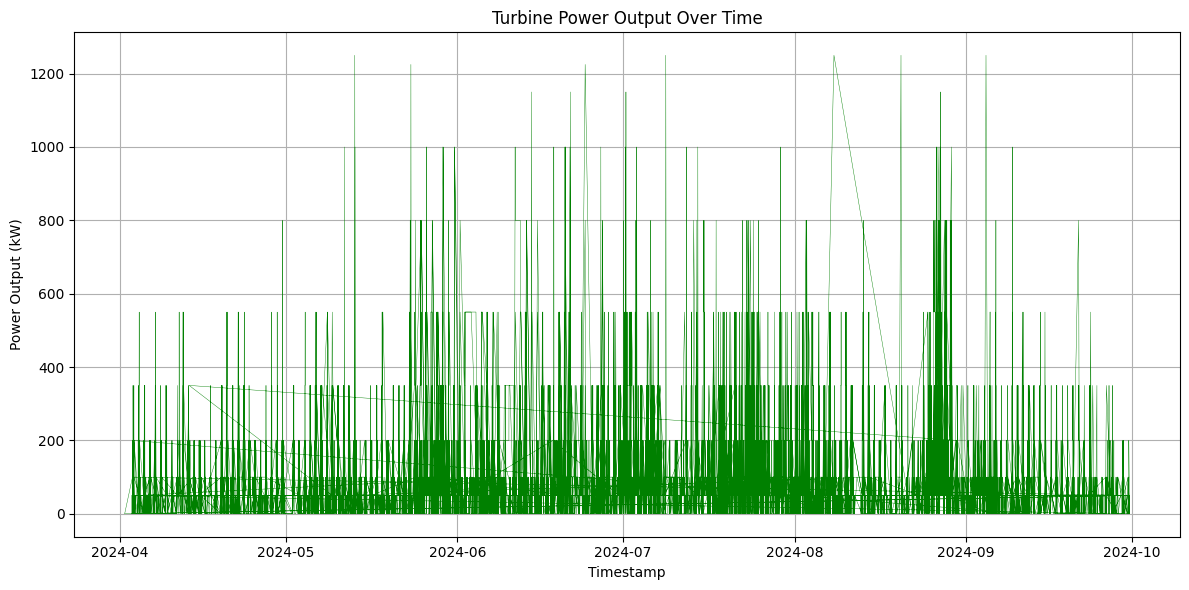

In [70]:
# Power output over time
plt.figure(figsize=(12, 6))
plt.plot(filtered_data["DATE"], filtered_data["power_output_kw"], color="green", linewidth=0.3)
plt.title("Turbine Power Output Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Power Output (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()


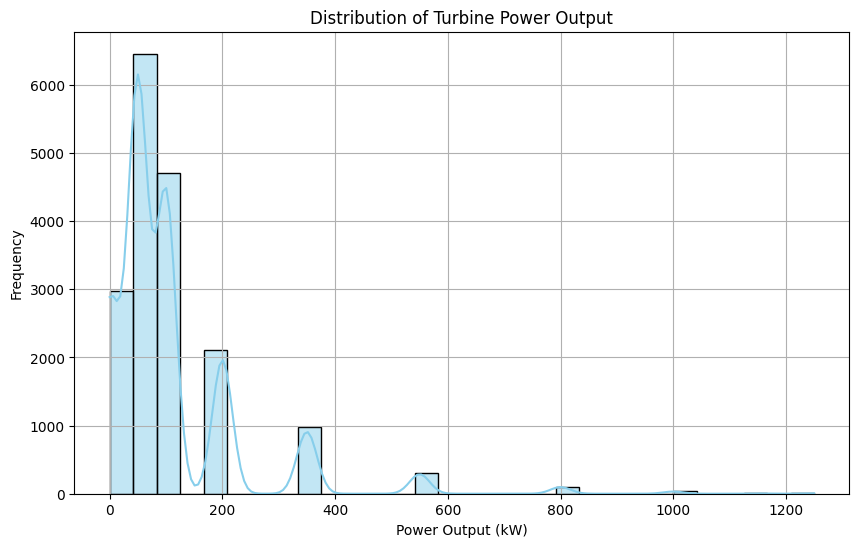

In [71]:
#histogram of full power curve
plt.figure(figsize=(10, 6))
sns.histplot(filtered_data["power_output_kw"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Turbine Power Output")
plt.xlabel("Power Output (kW)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [72]:
import numpy as np

# Define common missing values across ISD
missing_vals = ['+99999', '+999999', '+9999', '99999', '999999', '9999', '999', '99', '+999', '999.9']

# Apply replacement across all string-based columns
filtered_data.replace(missing_vals, np.nan, inplace=True)


In [73]:
filtered_data.isnull().sum()

STATION                 0
NAME                    0
LATITUDE                0
LONGITUDE               0
ELEVATION               0
DATE                    0
SOURCE                  0
REPORT_TYPE             0
CALL_SIGN               0
QUALITY_CONTROL         0
MA1                   961
TMP                     0
wind_direction_deg      0
wind_speed_mps          0
tmp_deg                 0
power_output_kw         0
dtype: int64

In [74]:
print(filtered_data["CALL_SIGN"].nunique())
print(filtered_data["QUALITY_CONTROL"].nunique())

1
1


In [75]:
#deleting all non necessary rows
filtered_data = filtered_data.drop(columns = ["CALL_SIGN", "QUALITY_CONTROL", "MA1", "REPORT_TYPE", "TMP"])

In [76]:
filtered_data.head(3)

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,SOURCE,wind_direction_deg,wind_speed_mps,tmp_deg,power_output_kw
54,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-04-20 03:00:00,4,180.0,4.1,29.0,50
147,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-05-16 12:00:00,4,340.0,4.1,31.8,50
179,43225099999,"KARWAR, IN",14.783333,74.133333,4.0,2024-05-24 12:00:00,4,320.0,5.1,33.4,100


In [77]:
print(data['SOURCE'].unique())
print(data['ELEVATION'].nunique())

[4]
14


In [78]:
filtered_data.drop(columns=['SOURCE'], inplace=True)

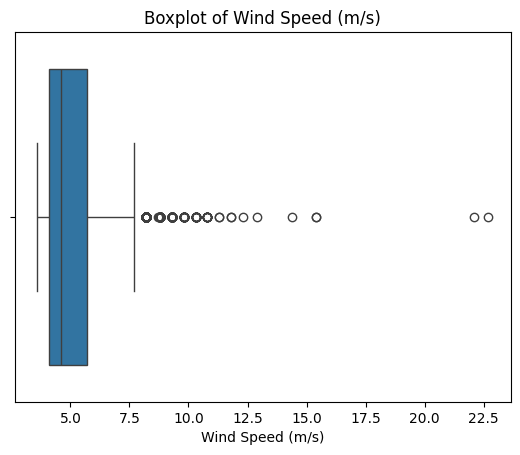

In [79]:
# Boxplot for wind speed
sns.boxplot(x=filtered_data['wind_speed_mps'])
plt.title("Boxplot of Wind Speed (m/s)")
plt.xlabel("Wind Speed (m/s)")
plt.show()

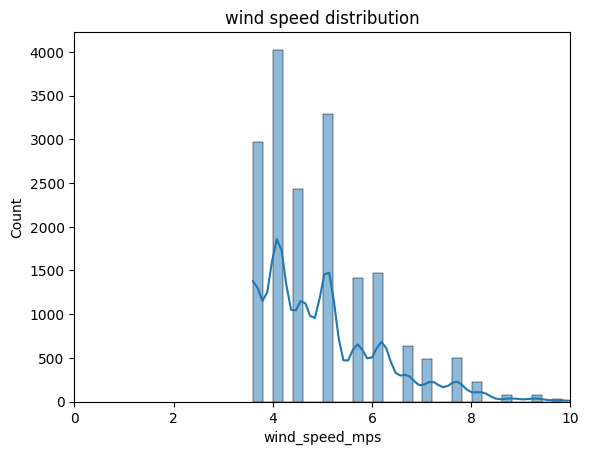

In [80]:
# wind speed distribution
data['DATE'] = pd.to_datetime(data['DATE'])
sns.histplot(filtered_data["wind_speed_mps"], kde = True, binwidth=0.2)
plt.xlim(0, 10)  # Focus on the actual data range
plt.title("wind speed distribution")
plt.show()

In [81]:
print(data[data["wind_speed_mps"] < 1.0]["wind_speed_mps"].value_counts())

wind_speed_mps
0.5    340
0.0      1
Name: count, dtype: int64


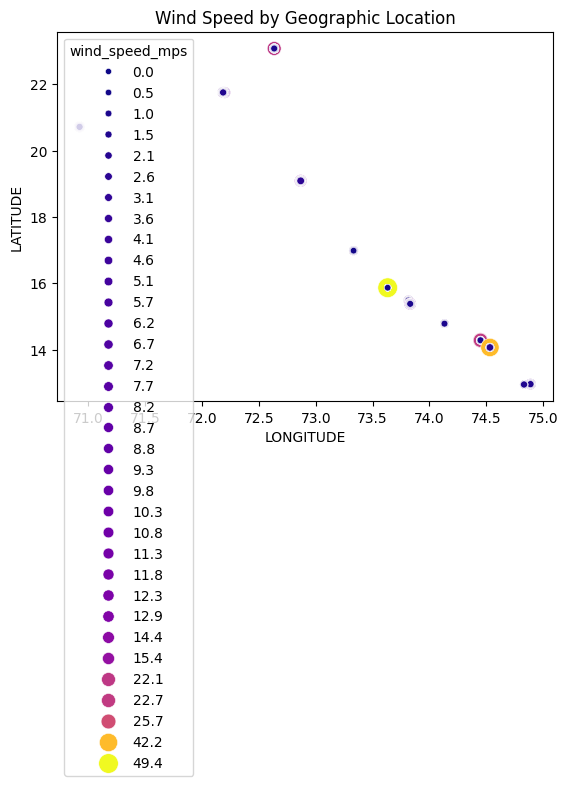

In [84]:
sns.scatterplot(
    data=data,
    x="LONGITUDE",
    y="LATITUDE",
    hue="wind_speed_mps",
    palette="plasma",      # try 'viridis', 'coolwarm', or 'turbo'
    size="wind_speed_mps", # optional: size varies by speed
    sizes=(20, 200),       # marker size range
    legend="full"
)
plt.title("Wind Speed by Geographic Location")
plt.show()


In [82]:
filtered_data.to_csv('cleaned_wind_data.csv', index=False)